# Task 4 – Major ML Project: Heart Disease Prediction

**Week 4 focus:** Full ML pipeline, model evaluation, optimization, and model saving.

**Objective:** Build a classification pipeline that predicts whether a patient is likely to have heart disease.

This notebook covers the Week 4 practice requirements as well:
1. Cross-validation with `cross_val_score`
2. `GridSearchCV` for SVM
3. Saving a trained model with `joblib`
4. Loading the saved model and predicting a new patient

> **Note:** The dataset is the UCI Heart Disease dataset. The notebook first looks for a local `heart.csv`; if it is not present, it downloads a UCI-derived CSV automatically when internet access is available. The UCI repository describes the Heart Disease dataset as a classification dataset with 303 Cleveland instances in its processed form.


In [1]:
# 1. Import libraries
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)

RANDOM_STATE = 42


In [2]:
# 2. Load the dataset
# If heart.csv exists in the same folder, it will be used.
# Otherwise, the notebook downloads a UCI-derived copy of the UCI Heart Disease dataset.

local_candidates = ["heart.csv", "heart-disease-dataset.csv"]

df = None
for path in local_candidates:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded local dataset: {path}")
        break

if df is None:
    url = "https://raw.githubusercontent.com/rikhuijzer/heart-disease-dataset/master/heart-disease-dataset.csv"
    df = pd.read_csv(url)
    print("Loaded the UCI Heart Disease dataset from the online copy.")

df.head()


Loaded the UCI Heart Disease dataset from the online copy.


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


In [3]:
# 3. Basic inspection and cleaning
print("Shape:", df.shape)
display(df.info())
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Convert all columns to numeric where possible and remove rows that cannot be converted.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)
display(df.describe().T)


Shape: (1190, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


None


Missing values:


age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64


Duplicate rows: 272

Shape after cleaning: (918, 12)


,count,mean,std,min,25%,50%,75%,max
age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
sex,918.0,0.789760,0.407701,0.0,1.00,1.0,1.0,1.0
chest_pain_type,918.0,3.251634,0.931031,1.0,3.00,4.0,4.0,4.0
resting_bp_s,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
fasting_blood_sugar,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
resting_ecg,918.0,0.603486,0.805968,0.0,0.00,0.0,1.0,2.0
max_heart_rate,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
exercise_angina,918.0,0.404139,0.490992,0.0,0.00,0.0,1.0,1.0
oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2


## 4. Define features and target

The target is binary:
- `0` = no heart disease
- `1` = heart disease

The UCI-derived file uses 11 predictor columns and one binary target column.


In [4]:
# 4. Prepare X and y
target_col = "target"

if target_col not in df.columns:
    # Support common Kaggle naming
    if "Target" in df.columns:
        target_col = "Target"
    elif "num" in df.columns:
        target_col = "num"
        df[target_col] = (df[target_col] > 0).astype(int)

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# If a dataset uses the original UCI multi-class target 0-4, convert to binary.
if y.nunique() > 2:
    y = (y > 0).astype(int)

print("Features:", list(X.columns))
print("Target distribution:")
display(y.value_counts().rename(index={0: "No disease", 1: "Disease"}))


Features: ['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope']
Target distribution:


target
Disease       508
No disease    410
Name: count, dtype: int64

In [5]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 734
Testing samples: 184


## 6. Logistic Regression

A scaled Logistic Regression model is used as the main interpretable baseline.


In [6]:
# 6. Train Logistic Regression
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_auc = roc_auc_score(y_test, logistic_prob)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"ROC-AUC  : {logistic_auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, logistic_pred, target_names=["No disease", "Disease"], zero_division=0))


Accuracy : 0.8859
Precision: 0.8716
Recall   : 0.9314
ROC-AUC  : 0.9014

Classification report:
              precision    recall  f1-score   support

  No disease       0.91      0.83      0.87        82
     Disease       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



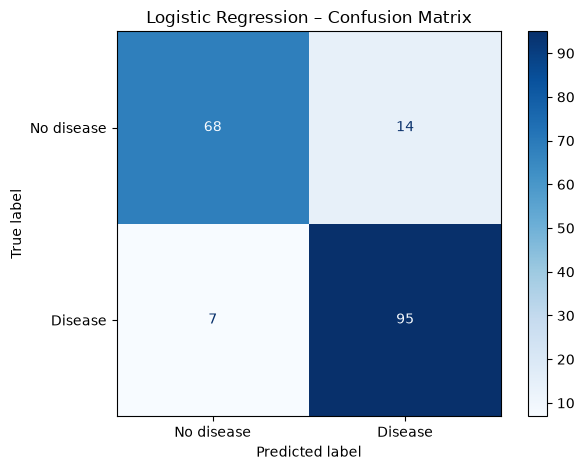

In [7]:
# 7. Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, logistic_pred,
    display_labels=["No disease", "Disease"],
    cmap="Blues"
)
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()


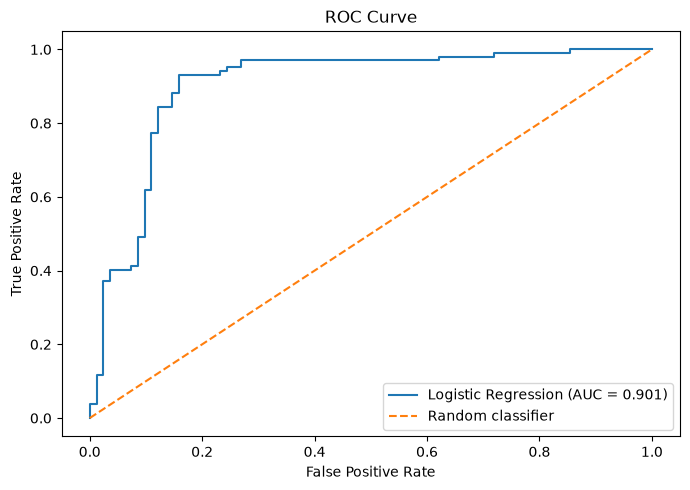

In [8]:
# 8. ROC curve
fpr, tpr, _ = roc_curve(y_test, logistic_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {logistic_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Decision Tree

A Decision Tree is trained as a second model for comparison.


In [9]:
# 9. Train Decision Tree
tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, tree_pred):.4f}")
print(f"Decision Tree Precision: {precision_score(y_test, tree_pred, zero_division=0):.4f}")
print(f"Decision Tree Recall: {recall_score(y_test, tree_pred, zero_division=0):.4f}")


Decision Tree Accuracy: 0.8152
Decision Tree Precision: 0.8333
Decision Tree Recall: 0.8333


## 10. Practice Question 1 – Cross-validation

Cross-validation estimates how consistently the Logistic Regression model performs across different training/validation splits.


In [10]:
# 10. 5-fold cross-validation
cv_scores = cross_val_score(logistic_model, X, y, cv=5, scoring="accuracy")

print("Cross-validation accuracy scores:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")


Cross-validation accuracy scores: [0.8043 0.8261 0.8043 0.8306 0.7541]
Mean CV accuracy: 0.8039
CV standard deviation: 0.0272


## 11. Practice Question 2 – GridSearchCV for SVM

Grid search tests several SVM hyperparameter combinations and selects the combination with the best cross-validation accuracy.


In [11]:
# 11. SVM pipeline and GridSearchCV
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=RANDOM_STATE))
])

param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_
svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Test precision: {precision_score(y_test, svm_pred, zero_division=0):.4f}")
print(f"Test recall: {recall_score(y_test, svm_pred, zero_division=0):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, svm_prob):.4f}")


Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV accuracy: 0.8583
Test accuracy: 0.8913
Test precision: 0.8596
Test recall: 0.9608
Test ROC-AUC: 0.9222


C:\Users\megha\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [12]:
# 12. Compare the main models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Tuned SVM"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, tree_pred, zero_division=0),
        precision_score(y_test, svm_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, tree_pred, zero_division=0),
        recall_score(y_test, svm_pred, zero_division=0)
    ]
})

display(results.round(4))


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.8859,0.8716,0.9314
1,Decision Tree,0.8152,0.8333,0.8333
2,Tuned SVM,0.8913,0.8596,0.9608


## 13. Practice Question 3 – Save the trained model

The tuned SVM pipeline is saved with `joblib`. Saving the whole pipeline is useful because preprocessing and the trained model are kept together.


In [13]:
# 13. Save the best model
model_filename = "heart_disease_svm_model.joblib"
joblib.dump(best_svm, model_filename)

print(f"Saved model to: {os.path.abspath(model_filename)}")


Saved model to: c:\Users\megha\OneDrive\Desktop\ML-AI-Internship\heart_disease_svm_model.joblib


## 14. Practice Question 4 – Load model and predict a new patient

The example below uses the first test-set patient as a demonstration so that the feature order is guaranteed to match the training data.


In [14]:
# 14. Load the saved model and make a prediction
loaded_model = joblib.load(model_filename)

new_patient = X_test.iloc[[0]]
actual = int(y_test.iloc[0])
prediction = int(loaded_model.predict(new_patient)[0])
probability = float(loaded_model.predict_proba(new_patient)[0, 1])

print("New patient features:")
display(new_patient)

print(f"Predicted class: {prediction} ({'Disease' if prediction == 1 else 'No disease'})")
print(f"Predicted probability of disease: {probability:.2%}")
print(f"Actual class: {actual} ({'Disease' if actual == 1 else 'No disease'})")


New patient features:


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope
356,46.0,1.0,4.0,115.0,0.0,0.0,0.0,113.0,1.0,1.5,2.0


Predicted class: 1 (Disease)
Predicted probability of disease: 95.18%
Actual class: 1 (Disease)


## 15. Final Conclusion

This project demonstrates a complete machine-learning workflow for heart disease classification: data loading, cleaning, train-test splitting, scaling, Logistic Regression and Decision Tree training, evaluation with accuracy/precision/recall, confusion matrix and ROC curve visualization, cross-validation, SVM hyperparameter optimization with GridSearchCV, and model persistence with joblib.

The final tuned SVM is selected as the saved model because it is optimized using cross-validation. The reported metrics should be interpreted as model-performance measurements, not as medical diagnosis. A real clinical system would require clinical validation, appropriate risk analysis, and professional oversight.
